# Задание 1 (Вариант 5)

$\qquad f_θ(x) = \frac{1}{(k-1)!θ^k} x^{k-1} e^{-x/θ} \mathbf{1}(x > 0)$

**Параметры эксперимента:**

$\qquad θ = 2$ (неизвестный параметр)

$\qquad k = 3$


## Теоретический анализ

Данное распределение является гамма-распределением - $Γ(k, θ)$

### Теоретический первый момент

$\qquad E[X] = k \cdot θ$

### Метод моментов:
Приравниваем теоретический момент к выборочному:

$\qquad k = 3$

$\qquad \bar{X} = k\hat{θ} = 3\hat{θ}$

Получаем оценку методом моментов:

$\qquad \hat{θ} = \frac{\bar{X}}{k} = \frac{\bar{X}}{3}$

### Свойства оценки:

**Несмещенность**

$\qquad E[\hat{θ}] = \frac{E[\bar{X}]}{k} = \frac{kθ}{k} = θ$

**Состоятельность**

$\qquad$ По ЗБЧ $\bar{X} \xrightarrow{P} kθ$, значит $\hat{θ} \xrightarrow{P} θ$

**Дисперсия**

$\qquad \text{Var}(\hat{θ}) = \frac{\text{Var}(\bar{X})}{k^2} = \frac{k*θ^2}{n*k^2} = \frac{θ^2}{nk}$

**MSE**

$\qquad \text{MSE}(\hat{θ}) = \text{Var}(\hat{θ}) + \text{Bias}^2(\hat{θ}) = \frac{θ^2}{nk} + 0^2 = \frac{θ^2}{nk}$


## Импорты


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

np.random.seed(2)


## Параметры эксперимента


In [40]:
K = 3
THETA = 2

# Функция для генерации выборки из гамма-распределения
def generate_gamma_sample(n, k, theta):
    return np.random.gamma(shape=k, scale=theta, size=n)

# Функция для вычисления оценки θ методом моментов
def estimate_theta(sample, k = K):
    sample_mean = np.mean(sample)
    theta_hat = sample_mean / k
    return theta_hat

# Функция для вычисления теоретических характеристик оценки
def theoretical_properties(n, k, theta):
    bias = 0
    variance = theta**2 / (n * k)
    mse = variance + bias*bias
    return {
        'n': n,
        'mean': theta,
        'bias': bias,
        'var': variance,
        'mse': mse,
    }


## Эксперимент

- ### Зададим массив объемов выборки
- ### Для каждого объема сгенерируем t выборок и вычислим оценки
- ### Построим визуализации


In [41]:
SAMPLE_SIZES = [10, 30, 50, 100, 200, 400, 600, 800, 1000, 2000, 4000, 6000, 8000, 10000]
M = 1000
CRIT_ERR_BOUND = 0.1

EMP_DATA = []
TH_DATA = []
ESTIMATIONS = {}

for n in SAMPLE_SIZES:
    errors = []
    ESTIMATIONS[n] = []

    # Процент критических ошибок
    err_rate = 0

    # Генерируем m выборок размера n
    for _ in range(M):
        sample = generate_gamma_sample(n, K, THETA)
        theta_hat = estimate_theta(sample, K)
        err = theta_hat - THETA
        ESTIMATIONS[n].append(theta_hat)
        errors.append(err)
        if err > CRIT_ERR_BOUND:
            err_rate += 1

    err_rate /= M
    errors = np.array(errors)

    # Эмпирические оценки
    ESTIMATIONS[n] = np.array(ESTIMATIONS[n])
    EMP_DATA.append({
        'n': n,
        'mean': np.mean(ESTIMATIONS[n]),
        'bias': np.mean(errors),
        'var': np.var(ESTIMATIONS[n], ddof=1),
        'mse': np.mean(errors**2),
        'err_rate': err_rate,
    })

    # Теоретические оценки
    TH_DATA.append(theoretical_properties(n, K, THETA))

df_emp_summary = pd.DataFrame(EMP_DATA)
print("EMPIRICAL ESTIMATIONS:")
print(df_emp_summary.round(6))
print()

df_th_summary = pd.DataFrame(TH_DATA)
print("THEORETICAL ESTIMATIONS:")
print(df_th_summary.round(6))


EMPIRICAL ESTIMATIONS:
        n      mean      bias       var       mse  err_rate
0      10  2.001426  0.001426  0.130279  0.130151     0.377
1      30  1.992183 -0.007817  0.045635  0.045650     0.287
2      50  2.002856  0.002856  0.025863  0.025845     0.271
3     100  1.996002 -0.003998  0.013693  0.013696     0.194
4     200  2.003419  0.003419  0.006977  0.006982     0.116
5     400  2.001099  0.001099  0.003237  0.003235     0.036
6     600  1.999756 -0.000244  0.002192  0.002190     0.015
7     800  2.001976  0.001976  0.001834  0.001836     0.016
8    1000  2.000442  0.000442  0.001315  0.001314     0.002
9    2000  2.000450  0.000450  0.000685  0.000684     0.000
10   4000  2.000226  0.000226  0.000334  0.000334     0.000
11   6000  2.000073  0.000073  0.000221  0.000221     0.000
12   8000  2.000457  0.000457  0.000168  0.000168     0.000
13  10000  2.000392  0.000392  0.000136  0.000136     0.000

THEORETICAL ESTIMATIONS:
        n  mean  bias       var       mse
0      10

## Визуализация: Разница между оценками


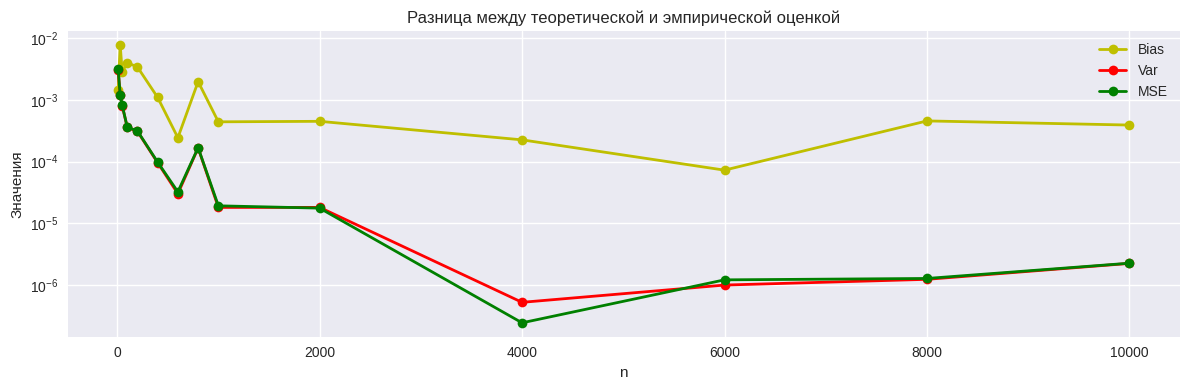

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

bias_diff = np.abs(df_emp_summary['bias'] - df_th_summary['bias'])
var_diff = np.abs(df_emp_summary['var'] - df_th_summary['var'])
mse_diff = np.abs(df_emp_summary['mse'] - df_th_summary['mse'])

ax.plot(df_emp_summary['n'], bias_diff, 'y-o', label='Bias', linewidth=2)
ax.plot(df_emp_summary['n'], var_diff, 'r-o', label='Var', linewidth=2)
ax.plot(df_emp_summary['n'], mse_diff, 'g-o', label='MSE', linewidth=2)

ax.set_xlabel('n')
ax.set_ylabel('Значения')
ax.set_title('Разница между теоретической и эмпирической оценкой')
ax.legend()
ax.grid(True)
ax.set_yscale('log')

plt.tight_layout()
plt.show()


## Визуализация: Распределение оценок

- ### Проанализируем распределение оценок для нескольких размеров выборки

$\qquad \hat{θ} = \frac{\bar{X}}{k} \xrightarrow{} U \sim N\left(θ, \frac{θ^2}{nk}\right)$


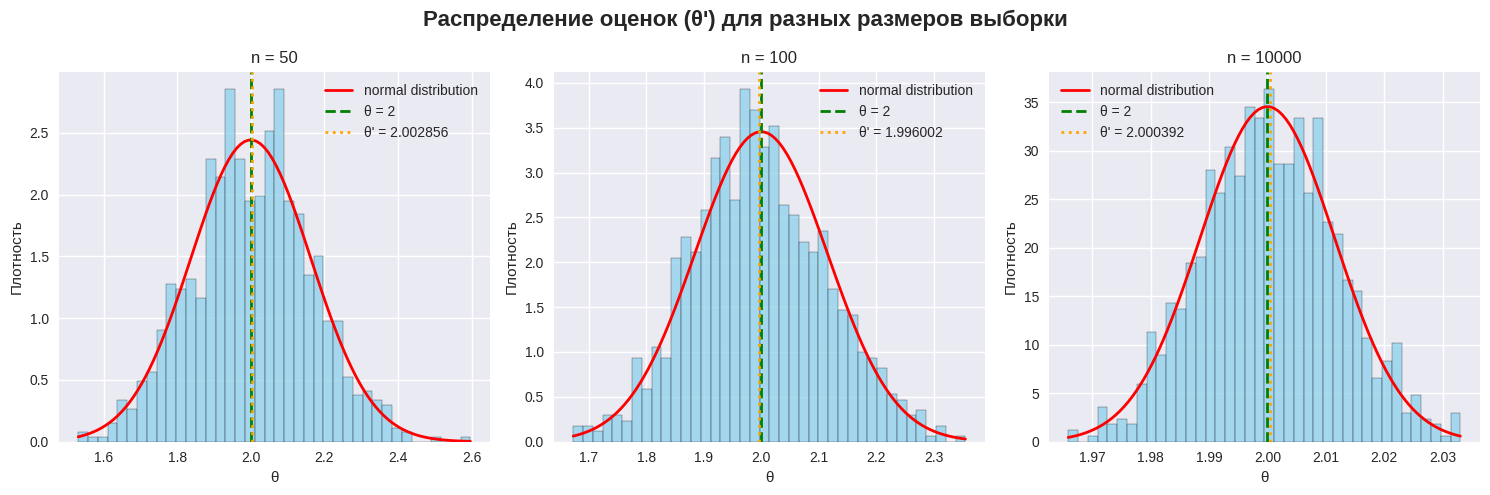

In [43]:
SIZES = [50, 100, 10000]

fig, axes = plt.subplots(1, len(SIZES), figsize=(15, 5))
fig.suptitle("Распределение оценок (θ') для разных размеров выборки", fontsize=16, fontweight='bold')

for i, n in enumerate(SIZES):
    estimates = ESTIMATIONS[n]
    axes[i].hist(estimates, bins=40, density=True, alpha=0.7, color='skyblue', edgecolor='black')

    # Теоретическое нормальное распределение
    x_range = np.linspace(estimates.min(), estimates.max(), 100)
    theoretical_pdf = stats.norm.pdf(x_range, THETA, np.sqrt((THETA * THETA) / (n * K)))
    axes[i].plot(x_range, theoretical_pdf, 'r-', linewidth=2, label=f'normal distribution')

    # Истинное значение
    axes[i].axvline(x=THETA, color='green', linestyle='--', linewidth=2, label=f'θ = {THETA}')

    # Эмпирическое среднее
    mean = EMP_DATA[SAMPLE_SIZES.index(n)]['mean']
    axes[i].axvline(x=mean, color='orange', linestyle=':', linewidth=2, label=f"θ' = {mean:.6f}")

    axes[i].set_title(f'n = {n}')
    axes[i].set_xlabel('θ')
    axes[i].set_ylabel('Плотность')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()


## Выводы и заключение

### Результаты эксперимента:

**1. Несмещенность**

- Эмпирическое смещение близко к 0 для всех размеров выборки

- Теоретическое смещение = 0 (доказано аналитически)

**2. Состоятельность**

- Дисперсия убывает как $\frac{θ^2}{nk} = \frac{4}{3n}$

- $MSE = Var \xrightarrow{} 0$

- Доля больших ошибок уменьшается с ростом n

**3. Эффективность**

- Оценка асимптотически нормальна

### Практические выводы:

- Для надежной оценки лучше брать n >= 1000

- Асимптотическая нормальность подтверждается экспериментально

- Метод моментов дает простую и эффективную оценку для гамма-распределения
